In [16]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score

import joblib
import os

# Configuration
RANDOM_STATE = 42
np.random. seed(RANDOM_STATE)


In [17]:
# Chargement des données
data_path = 'data/row/clean_metabric_final.csv'
data = pd.read_csv(data_path, index_col=0)

print(f"Données chargées : {data.shape}")
print(f"{data.shape[0]} patients, {data.shape[1]} colonnes")

# Séparer features et cibles
target_cols = ['aggressiveness_score', 'growth_rate', 'evolution_6m']
X = data. drop(columns=target_cols)
y = data[target_cols]

print(f"\nFeatures (X) : {X.shape}")
print(f"Cibles (y) : {y.shape}")
print(f"Colonnes cibles : {list(y.columns)}")

Données chargées : (1904, 30)
1904 patients, 30 colonnes

Features (X) : (1904, 27)
Cibles (y) : (1904, 3)
Colonnes cibles : ['aggressiveness_score', 'growth_rate', 'evolution_6m']


In [18]:
# Aperçu des données
print("Aperçu des données :\n")
print(data.head())

print("\n\nStatistiques des cibles :\n")
print(y.describe())

# Distribution evolution_6m
print("\n\nDistribution evolution_6m :")
print(y['evolution_6m'].value_counts().sort_index())
print(f"\nValeurs manquantes : {data. isna().sum().sum()}")

Aperçu des données :

   age_at_diagnosis  tumor_size  nottingham_prognostic_index  \
0             75.65        22.0                        6.044   
1             43.19        10.0                        4.020   
2             48.87        15.0                        4.030   
3             47.68        25.0                        4.050   
4             76.97        40.0                        6.080   

   lymph_nodes_examined_positive  mutation_count pik3ca_mut tp53_mut  \
0                            5.0             5.0          0        0   
1                            0.0             2.0          0    H178P   
2                            1.0             2.0     H1047R        0   
3                            3.0             1.0      E542K        0   
4                            5.0             2.0          0    S241F   

  gata3_mut map3k1_mut cdh1_mut  ...  overall_survival_binary  \
0         0          0        0  ...                      0.0   
1         0          0        

In [19]:
# Split train/test (80/20)
# Stratification sur evolution_6m pour équilibrer les classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y['evolution_6m']
)

print(f"Train : {X_train.shape[0]} patients ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]} patients ({X_test. shape[0]/len(X)*100:.1f}%)")

# Vérifier distribution
print("\nDistribution evolution_6m :")
print(f"Train : {y_train['evolution_6m'].value_counts(normalize=True). sort_index(). values}")
print(f"Test  : {y_test['evolution_6m'].value_counts(normalize=True).sort_index().values}")

Train : 1523 patients (80.0%)
Test  : 381 patients (20.0%)

Distribution evolution_6m :
Train : [0.41300066 0.40052528 0.18647406]
Test  : [0.41469816 0.39895013 0.18635171]


In [21]:
# Standardisation (fit sur train, transform sur train et test)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler. transform(X_train)
X_test_scaled = scaler. transform(X_test)

# Reconvertir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Standardisation terminée")
print(f"Moyenne train : {X_train_scaled.mean(). mean():.4f} (attendu ≈ 0)")
print(f"Std train     : {X_train_scaled. std().mean():.4f} (attendu ≈ 1)")

Standardisation terminée
Moyenne train : -0.0000 (attendu ≈ 0)
Std train     : 0.9549 (attendu ≈ 1)


In [22]:
# Définir les modèles à comparer
models = {
    'Random Forest': MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    'Gradient Boosting': MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            random_state=RANDOM_STATE
        )
    )
}

# Entraîner et évaluer chaque modèle
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Modèle : {name}")
    print('='*60)
    
    # Entraînement
    model.fit(X_train_scaled, y_train)
    
    # Prédictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Métriques pour chaque cible
    # Aggressiveness Score
    r2_aggr_train = r2_score(y_train. iloc[:, 0], y_train_pred[:, 0])
    r2_aggr_test = r2_score(y_test.iloc[:, 0], y_test_pred[:, 0])
    mae_aggr = mean_absolute_error(y_test.iloc[:, 0], y_test_pred[:, 0])
    
    # Growth Rate
    r2_growth_train = r2_score(y_train.iloc[:, 1], y_train_pred[:, 1])
    r2_growth_test = r2_score(y_test.iloc[:, 1], y_test_pred[:, 1])
    mae_growth = mean_absolute_error(y_test.iloc[:, 1], y_test_pred[:, 1])
    
    # Evolution 6M (classification)
    y_test_pred_class = np.round(y_test_pred[:, 2]). astype(int). clip(0, 2)
    acc_test = accuracy_score(y_test. iloc[:, 2], y_test_pred_class)
    
    # Afficher résultats
    print(f"\nAggressiveness Score :")
    print(f"  R² train : {r2_aggr_train:.4f}")
    print(f"  R² test  : {r2_aggr_test:.4f}")
    print(f"  MAE test : {mae_aggr:.4f}")
    
    print(f"\nGrowth Rate :")
    print(f"  R² train : {r2_growth_train:.4f}")
    print(f"  R² test  : {r2_growth_test:.4f}")
    print(f"  MAE test : {mae_growth:.4f}")
    
    print(f"\nEvolution 6M :")
    print(f"  Accuracy : {acc_test:.4f} ({acc_test*100:.1f}%)")
    
    # Stocker résultats
    results[name] = {
        'model': model,
        'r2_aggr': r2_aggr_test,
        'r2_growth': r2_growth_test,
        'acc_evol': acc_test,
        'predictions': y_test_pred
    }


Modèle : Random Forest

Aggressiveness Score :
  R² train : 0.9973
  R² test  : 0.9767
  MAE test : 0.0616

Growth Rate :
  R² train : 0.9981
  R² test  : 0.9886
  MAE test : 0.3527

Evolution 6M :
  Accuracy : 0.9921 (99.2%)

Modèle : Gradient Boosting

Aggressiveness Score :
  R² train : 0.9999
  R² test  : 0.9799
  MAE test : 0.0656

Growth Rate :
  R² train : 1.0000
  R² test  : 0.9945
  MAE test : 0.2394

Evolution 6M :
  Accuracy : 0.9948 (99.5%)


In [23]:
# Comparer les modèles
comparison = pd.DataFrame({
    'Modèle': list(results.keys()),
    'R² Aggressiveness': [results[m]['r2_aggr'] for m in results. keys()],
    'R² Growth Rate': [results[m]['r2_growth'] for m in results. keys()],
    'Accuracy Evolution': [results[m]['acc_evol'] for m in results.keys()]
})

# Score global (pondéré)
comparison['Score Global'] = (
    comparison['R² Aggressiveness'] * 0.4 +
    comparison['R² Growth Rate'] * 0.4 +
    comparison['Accuracy Evolution'] * 0.2
)

print("\nComparaison des modèles :\n")
print(comparison)

# Sélectionner le meilleur
best_model_name = comparison. loc[comparison['Score Global'].idxmax(), 'Modèle']
final_model = results[best_model_name]['model']
y_pred_final = results[best_model_name]['predictions']

print(f"Meilleur modèle : {best_model_name}")
print(f"Score global : {comparison['Score Global'].max():.4f}")



Comparaison des modèles :

              Modèle  R² Aggressiveness  R² Growth Rate  Accuracy Evolution  \
0      Random Forest           0.976694        0.988555            0.992126   
1  Gradient Boosting           0.979893        0.994540            0.994751   

   Score Global  
0      0.984525  
1      0.988724  
Meilleur modèle : Gradient Boosting
Score global : 0.9887


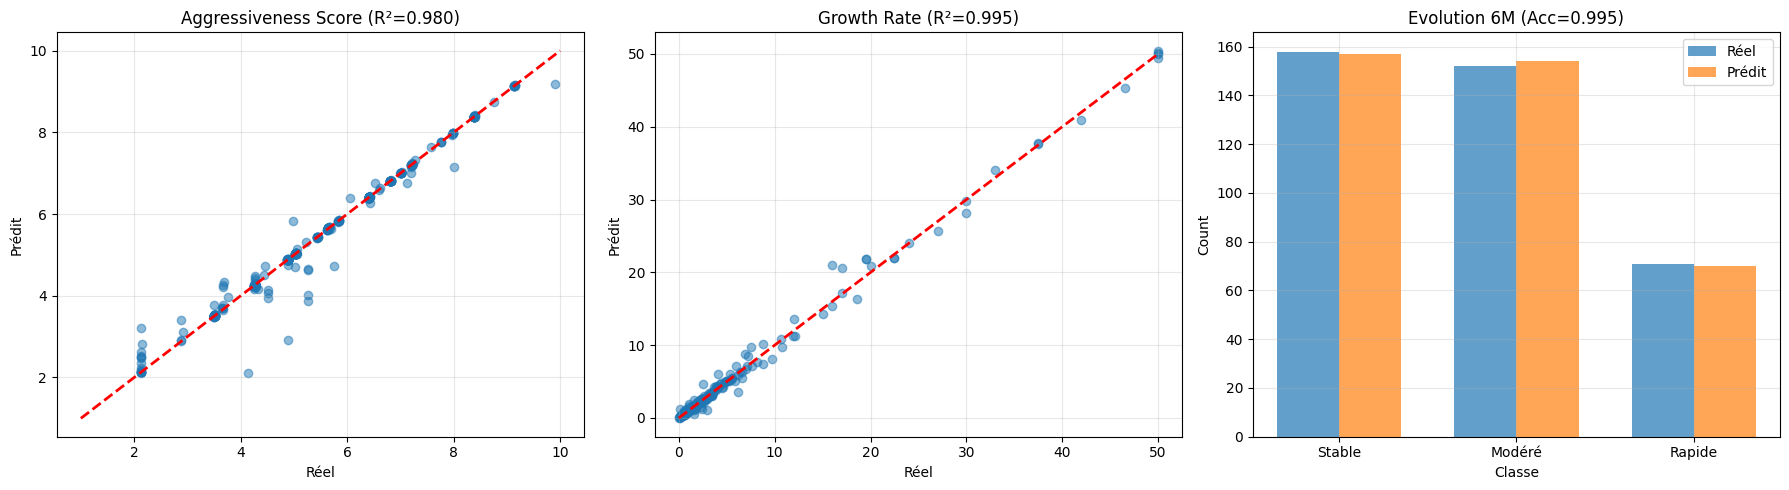

In [26]:
# Visualisation : Prédictions vs Réel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Aggressiveness Score
axes[0]. scatter(y_test. iloc[:, 0], y_pred_final[:, 0], alpha=0.5)
axes[0].plot([1, 10], [1, 10], 'r--', lw=2)
axes[0].set_xlabel('Réel')
axes[0].set_ylabel('Prédit')
axes[0].set_title(f'Aggressiveness Score (R²={results[best_model_name]["r2_aggr"]:.3f})')
axes[0]. grid(True, alpha=0.3)

# Growth Rate
axes[1].scatter(y_test.iloc[:, 1], y_pred_final[:, 1], alpha=0.5)
axes[1].plot([0, 50], [0, 50], 'r--', lw=2)
axes[1].set_xlabel('Réel')
axes[1].set_ylabel('Prédit')
axes[1]. set_title(f'Growth Rate (R²={results[best_model_name]["r2_growth"]:.3f})')
axes[1].grid(True, alpha=0.3)

# Evolution 6M - Distribution
y_pred_class = np.round(y_pred_final[:, 2]).astype(int). clip(0, 2)
pred_dist = pd.Series(y_pred_class). value_counts().sort_index()
true_dist = y_test.iloc[:, 2].value_counts().sort_index()

x = np.arange(3)
width = 0.35
axes[2].bar(x - width/2, true_dist, width, label='Réel', alpha=0.7)
axes[2].bar(x + width/2, pred_dist, width, label='Prédit', alpha=0.7)
axes[2].set_xlabel('Classe')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Evolution 6M (Acc={results[best_model_name]["acc_evol"]:.3f})')
axes[2]. set_xticks(x)
axes[2].set_xticklabels(['Stable', 'Modéré', 'Rapide'])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

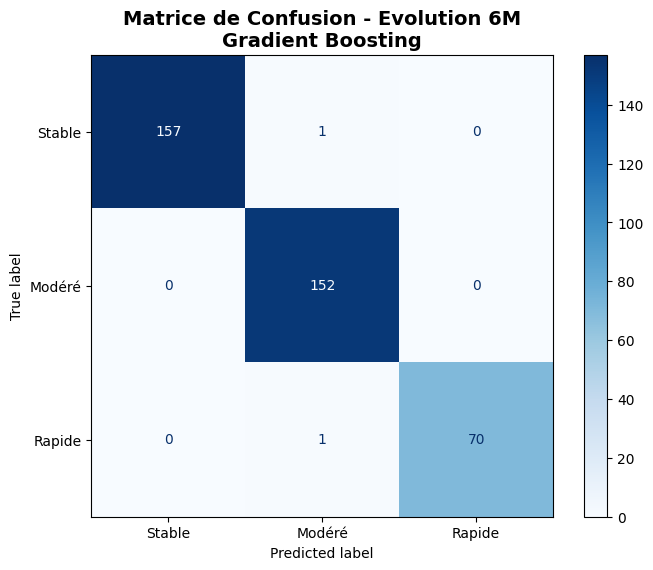


Matrice de confusion :
[[157   1   0]
 [  0 152   0]
 [  0   1  70]]

Précision globale : 0.995


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matrice de confusion pour Evolution 6M
y_pred_class = np.round(y_pred_final[:, 2]). astype(int).clip(0, 2)
cm = confusion_matrix(y_test.iloc[:, 2], y_pred_class)

# Afficher
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stable', 'Modéré', 'Rapide'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Matrice de Confusion - Evolution 6M\n{best_model_name}', fontsize=14, fontweight='bold')
plt.show()

print("\nMatrice de confusion :")
print(cm)
print(f"\nPrécision globale : {accuracy_score(y_test.iloc[:, 2], y_pred_class):.3f}")

In [28]:
# Créer dossier models
if not os.path.exists('models'):
    os.makedirs('models')

# Sauvegarder modèle et scaler
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path = f'models/metabric_model_{best_model_name. lower(). replace(" ", "_")}_{timestamp}.pkl'
scaler_path = f'models/metabric_scaler_{timestamp}.pkl'

joblib.dump(final_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Modèle sauvegardé : {model_path}")
print(f"Scaler sauvegardé : {scaler_path}")

# Sauvegarder résultats
results_summary = {
    'model': best_model_name,
    'timestamp': timestamp,
    'r2_aggressiveness': results[best_model_name]['r2_aggr'],
    'r2_growth_rate': results[best_model_name]['r2_growth'],
    'accuracy_evolution': results[best_model_name]['acc_evol'],
    'n_train': len(X_train),
    'n_test': len(X_test)
}

print("\nRésumé :")
for key, value in results_summary. items():
    print(f"  {key}: {value}")

Modèle sauvegardé : models/metabric_model_gradient_boosting_20251212_195341.pkl
Scaler sauvegardé : models/metabric_scaler_20251212_195341.pkl

Résumé :
  model: Gradient Boosting
  timestamp: 20251212_195341
  r2_aggressiveness: 0.9798934768821042
  r2_growth_rate: 0.9945402700286432
  accuracy_evolution: 0.994750656167979
  n_train: 1523
  n_test: 381
